## Import Modules




In [69]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

from simpeg import maps
from simpeg.potential_fields import gravity
from simpeg.utils import plot2Ddata, model_builder
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils,
)

## Topography Generation
(N, 3) array




In [70]:
[x_topo, y_topo] = np.meshgrid(np.linspace(-200, 200, 41), np.linspace(-200, 200, 41))
z_topo = -15 * np.exp(-(x_topo**2 + y_topo**2) / 80**2)
x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[x_topo, y_topo, z_topo] 

## Tensor Mesh Generation

In [71]:
dh = 5.0
hx = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hy = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hz = [(dh, 5, -1.3), (dh, 15)]
mesh = TensorMesh([hx, hy, hz], "CCN")

## Mapping (True) Density Contrast

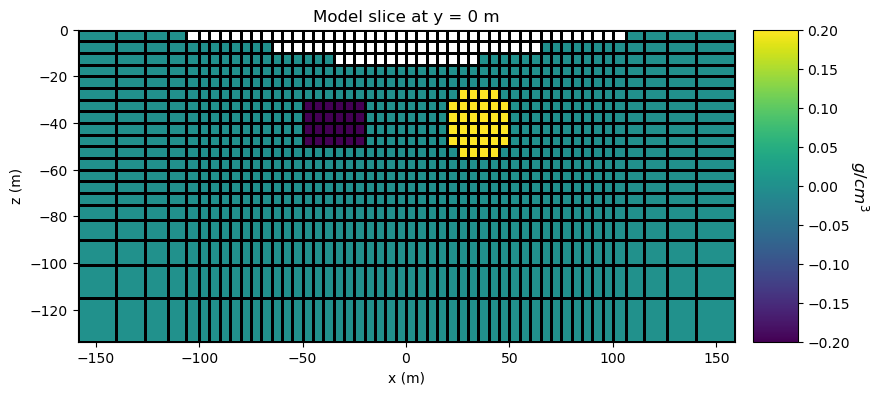

In [72]:
# Density contrast
background_density = 0.0  #g/cc
block_density = -0.2  #g/cc
sphere_density = 0.2  #g/cc

# Define indices of cells above & below surface (earth & air)
ind_active = active_from_xyz(mesh, topo_xyz)
nC = int(ind_active.sum())
model_map = maps.IdentityMap(nP=nC)
true_model = background_density * np.ones(nC)

# Define the block
ind_block = (
    (mesh.gridCC[ind_active, 0] > -50.0)
    & (mesh.gridCC[ind_active, 0] < -20.0)
    & (mesh.gridCC[ind_active, 1] > -15.0)
    & (mesh.gridCC[ind_active, 1] < 15.0)
    & (mesh.gridCC[ind_active, 2] > -50.0)
    & (mesh.gridCC[ind_active, 2] < -30.0)
)
true_model[ind_block] = block_density

# Define the sphere (SIMPEG utility)
ind_sphere = model_builder.get_indices_sphere(
    np.r_[35.0, 0.0, -40.0], 15.0, mesh.gridCC
)
ind_sphere = ind_sphere[ind_active]
true_model[ind_sphere] = sphere_density

# Plot Density Contrast Model
fig = plt.figure(figsize=(9, 4))
plotting_map = maps.InjectActiveCells(mesh, ind_active, np.nan)

ax1 = fig.add_axes([0.1, 0.12, 0.73, 0.78])
mesh.plot_slice(
    plotting_map * true_model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    clim=(np.min(true_model), np.max(true_model)),
    pcolor_opts={"cmap": "viridis"},
)
ax1.set_title("Model slice at y = 0 m")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.85, 0.12, 0.05, 0.78])
norm = mpl.colors.Normalize(vmin=np.min(true_model), vmax=np.max(true_model))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.viridis
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=12)

plt.show()

## Defining the Ideal Survey

(N, 3) array to define the xyz locations and field components
which are to be measured of true_model




In [95]:
# Define the observation locations (N, 3) array
x = np.linspace(-80.0, 80.0, 17)
y = np.linspace(-80.0, 80.0, 17)
x, y = np.meshgrid(x, y)
x, y = mkvc(x.T), mkvc(y.T)
fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z = fun_interp(np.c_[x, y]) + 5.0
receiver_locations = np.c_[x, y, z]
components = ["gz"]  # z-component of gravity (mGal), downward positive

# Weird SIMPEG library shit...
receiver_list = gravity.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_list]
source_field = gravity.sources.SourceField(receiver_list=receiver_list)
survey = gravity.survey.Survey(source_field)

## Foward Gravity Solver

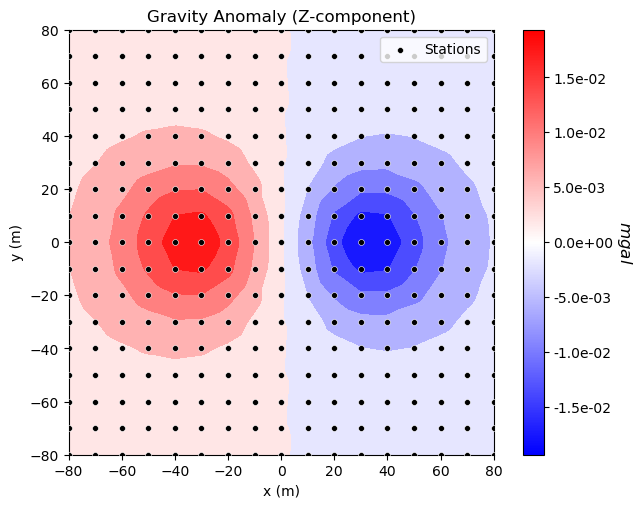

In [ ]:
simulation = gravity.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    rhoMap=model_map,
    active_cells=ind_active,
    store_sensitivities="forward_only",
    engine="choclo",
)

dpred = simulation.dpred(true_model)

# Plot
fig = plt.figure(figsize=(7, 5))

v_max = np.max(np.abs(dpred))

ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.85])
plot2Ddata(
    receiver_list[0].locations,
    dpred,
    clim=(-v_max, v_max),
    ax=ax1,
    contourOpts={"cmap": "bwr"},
)
ax1.set_title("Gravity Anomaly (Z-component)")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

# Overlay survey locations as dots
xy = receiver_list[0].locations[:, :2]        # (N, 2) -> x, y
ax1.scatter(
    xy[:, 0], xy[:, 1],
    s=18, marker='o', c='k',
    edgecolors='w', linewidths=0.4,
    zorder=3, label='Stations'
)
ax1.legend(loc='upper right', frameon=True)
# Optional: keep axes scaling consistent
ax1.set_aspect('equal', adjustable='box')

ax2 = fig.add_axes([0.82, 0.1, 0.03, 0.85])
norm = mpl.colors.Normalize(vmin=-v_max, vmax=v_max)
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr, format="%.1e"
)
cbar.set_label("$mgal$", rotation=270, labelpad=15, size=12)

plt.show()

## Initializing Synthetic (Realistic) Density Contrast

In [98]:
synthetic_model = np.zeros(nC)

## Synthetic (Realistic) Data Generation

Generate realistic gravimetry measurement data.

In [ ]:
# build survey + simulation as usual...
syn = simulation.make_synthetic_data(
    true_model,                 # model in g/cc
    relative_error=0.01,        # 1% relative
    noise_floor=0.002,           # 0.02 mGal absolute floor
    add_noise=True,
    random_seed=42
)

dobs = syn.dobs  # noisy data (mGal)
uncertainties = syn.standard_deviation  # per-datum σ (mGal)

## Defining the Synthetic (Realistic) Survey

(N, 3) array to define the xyz locations and field components
which are to be measured of synthetic_model. Can be the same as true_model survey.




In [86]:
# Define the observation locations (N, 3) array
x = np.linspace(-80.0, 80.0, 17)
y = np.linspace(-80.0, 80.0, 17)
x, y = np.meshgrid(x, y)
x, y = mkvc(x.T), mkvc(y.T)
fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z = fun_interp(np.c_[x, y]) + 5.0
receiver_locations = np.c_[x, y, z]
components = ["gz"]  # z-component of gravity (mGal), downward positive

# Weird SIMPEG library shit...
receiver_list = gravity.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_list]
source_field = gravity.sources.SourceField(receiver_list=receiver_list)
survey = gravity.survey.Survey(source_field)
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

## Inverse Gravity Solver (L2 Norm or IRLS)

Minimize residual + regularization to find density contrast

In [93]:
# L2 Norm: ||W(d_pred(m) - d_obs)||^2
dmis = data_misfit.L2DataMisfit(data=data_object, simulation=simulation)  

# Tikhonov regularization (smooths it out) <-- lowkey unrealistic... good for macro density contrast
reg = regularization.WeightedLeastSquares(
    mesh, active_cells=ind_active, mapping=model_map
)

# # Sparse (IRLS) regulatization (encourages sharp features) <-- more realistic
# reg = regularization.Sparse(mesh, active_cells=ind_active, mapping=model_map)
# reg.norms = [0, 2, 2, 2]

# update_IRLS = directives.UpdateIRLS(
#     f_min_change=1e-4,
#     max_irls_iterations=30,
#     irls_cooling_factor=1.5,
#     misfit_tolerance=1e-2,
# )

# Gauss-Newton (Hessian Search)
opt = optimization.ProjectedGNCG(
    maxIter=10, lower=-1.0, upper=1.0, maxIterLS=20, maxIterCG=10, tolCG=1e-3
)

inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=1e1)
beta_schedule = directives.BetaSchedule(coolingFactor=5, coolingRate=1)
save_iteration = directives.SaveOutputEveryIteration(save_txt=False)
update_jacobi = directives.UpdatePreconditioner()
target_misfit = directives.TargetMisfit(chifact=1)
sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)

directives_list = [
    sensitivity_weights,
    starting_beta,
    beta_schedule,
    save_iteration,
    update_jacobi,
    target_misfit, # comment out for IRLS
]

inv = inversion.BaseInversion(inv_prob, directives_list)

recovered_model = inv.run(synthetic_model)


Running inversion with SimPEG v0.24.0
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.

                    simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                    ***Done using the default solver Mumps and no solver_opts.***
                    
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  2.88e+02  2.75e+03  0.00e+00  2.

## Plotting True Model and Recovered Model




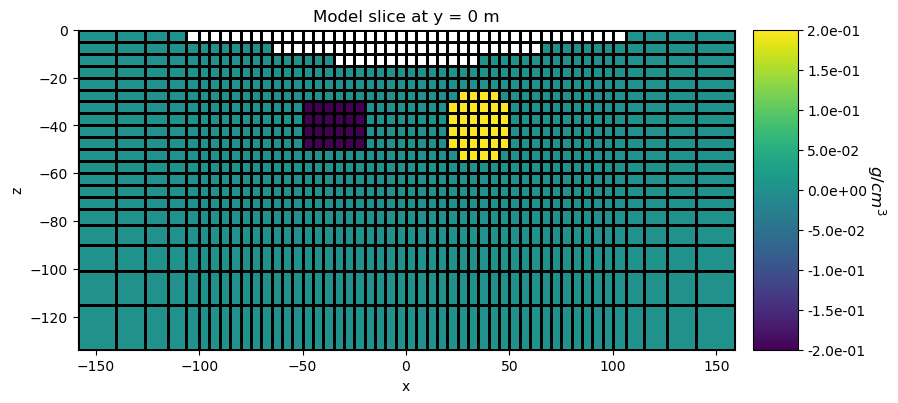

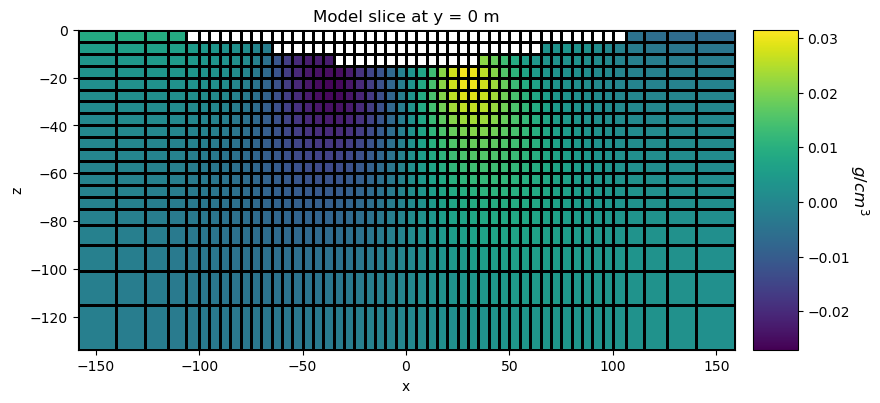

In [94]:
# Plot True Model
fig = plt.figure(figsize=(9, 4))
plotting_map = maps.InjectActiveCells(mesh, ind_active, np.nan)

ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])
mesh.plot_slice(
    plotting_map * true_model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    clim=(np.min(true_model), np.max(true_model)),
    pcolor_opts={"cmap": "viridis"},
)
ax1.set_title("Model slice at y = 0 m")


ax2 = fig.add_axes([0.85, 0.1, 0.05, 0.8])
norm = mpl.colors.Normalize(vmin=np.min(true_model), vmax=np.max(true_model))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.viridis, format="%.1e"
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=12)

plt.show()

# Plot Recovered Model
fig = plt.figure(figsize=(9, 4))
plotting_map = maps.InjectActiveCells(mesh, ind_active, np.nan)

ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])
mesh.plot_slice(
    plotting_map * recovered_model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    clim=(np.min(recovered_model), np.max(recovered_model)),
    pcolor_opts={"cmap": "viridis"},
)
ax1.set_title("Model slice at y = 0 m")

ax2 = fig.add_axes([0.85, 0.1, 0.05, 0.8])
norm = mpl.colors.Normalize(vmin=np.min(recovered_model), vmax=np.max(recovered_model))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.viridis
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=12)

plt.show()

## Comparing Signals

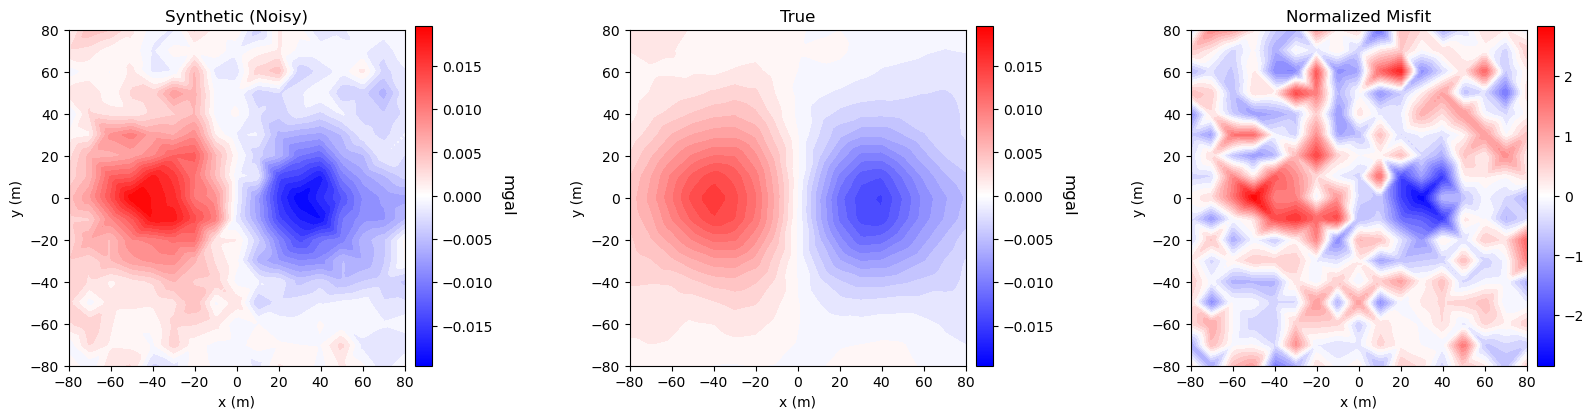

In [103]:
dpred = inv_prob.dpred

# Synethic (Noisy) | True | Normalized data misfit
data_array = np.c_[dobs, dpred, (dobs - dpred) / uncertainties]

fig = plt.figure(figsize=(17, 4))
plot_title = ["Synthetic (Noisy)", "True", "Normalized Misfit"]
plot_units = ["mgal", "mgal", ""]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(data_array[:, 2]))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.33 * ii + 0.03, 0.11, 0.23, 0.84])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        clim=(-v_lim[ii], v_lim[ii]),
        contourOpts={"cmap": "bwr"},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    ax1[ii].set_ylabel("y (m)")

    ax2[ii] = fig.add_axes([0.33 * ii + 0.25, 0.11, 0.01, 0.85])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="vertical", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], rotation=270, labelpad=15, size=12)

plt.show()